In [1]:
import pandas as pd
import numpy as np
import sys
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.metrics.fidelity.UnivariateSimilarity import UnivariateSimilarity
from SynOmics.processing.metadata import MetaData
import os
from SynOmics.processing.postprocessing import post_masking


os.makedirs("UniClinicalSimi", exist_ok = True)
or_data = pd.read_csv("Data/original_data.csv", index_col = 0)
clinical_or_data = or_data.iloc[:,0:54]
masked_clinical_or_data = post_masking(clinical_or_data)

ordinal_cat_columns = ["Mstage", "Tx_Start_ECOG",
                       "numPriorTherapies","biopsyContext"]
metadata = MetaData.get_metadata(data = masked_clinical_or_data, 
                                 threshold_unique_values = 10, 
                                    ordinal_features = ordinal_cat_columns)
seeds = [42,0,1,2,3]

In [2]:
from typing import Dict, Optional, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from scipy import stats
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl


def plot_violin_with_pvalue_heatmap(
    scores_dict: Dict[str, np.ndarray],
    title: Optional[str] = None,
    figsize: Tuple[int, int] = (14, 6),
    order: Optional[list] = None,
    palette='Set2',
    alpha: float = 0.05,
    cmap_green: str = 'Greens',
    pink_color: str = '#ffd6e0',
    white_color: Tuple[float, float, float] = (1.0, 1.0, 1.0),
    test: str = 'ranksums',
    annotate: bool = True,
    adjusted: bool = True,
    fontsize: int = 11,
):
    # Basic validation
    if not scores_dict or len(scores_dict) < 2:
        raise ValueError("scores_dict must contain at least two groups to compare.")

    methods = list(scores_dict.keys()) if order is None else order
    missing = [m for m in methods if m not in scores_dict]
    if missing:
        raise ValueError(f"The following methods specified in order are missing from scores_dict: {missing}")

    # Build DataFrame for plotting (drop NaNs)
    records = []
    for m in methods:
        arr = np.asarray(scores_dict[m])
        arr = arr[~np.isnan(arr)]
        for v in arr:
            records.append((m, float(v)))
    df = pd.DataFrame(records, columns=['method', 'score'])
    if df.empty:
        raise ValueError("After removing NaNs, no data remains to plot.")

    # Compute pairwise p-values using Wilcoxon rank-sum (ranksums)
    n = len(methods)
    pmat = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods, dtype=float)
    statmat = pd.DataFrame(np.nan, index=methods, columns=methods, dtype=float)

    for i, j in itertools.combinations(range(n), 2):
        m1 = methods[i]
        m2 = methods[j]
        a = df.loc[df['method'] == m1, 'score'].values
        b = df.loc[df['method'] == m2, 'score'].values

        if len(a) < 2 or len(b) < 2:
            stat, p = np.nan, np.nan
        else:
            if test == 'ranksums':
                stat, p = stats.ranksums(a, b)
            else:
                raise ValueError("Unsupported test. Only 'ranksums' supported in this function.")
        pmat.loc[m1, m2] = pmat.loc[m2, m1] = p
        statmat.loc[m1, m2] = statmat.loc[m2, m1] = stat

    # Diagonal set to 0 for convenience (not used for significance)
    np.fill_diagonal(pmat.values, 0.0)
    np.fill_diagonal(statmat.values, 0.0)

    # If requested, adjust p-values for multiple testing (Benjamini-Hochberg FDR)
    pmat_used = pmat.copy()
    if adjusted:
        try:
            from statsmodels.stats.multitest import multipletests
        except ImportError as e:
            raise ImportError("statsmodels is required to adjust p-values. Install it (pip install statsmodels).") from e

        # collect upper triangle p-values (i < j)
        idx_pairs = []
        pvals = []
        for i in range(n):
            for j in range(i + 1, n):
                p = pmat.iat[i, j]
                if np.isnan(p):
                    p = 1.0
                pvals.append(p)
                idx_pairs.append((i, j))

        if len(pvals) > 0:
            rej, pvals_adj, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
            # build adjusted p-value DataFrame (symmetric)
            pmat_adj = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods, dtype=float)
            for (i, j), padj in zip(idx_pairs, pvals_adj):
                pmat_adj.iat[i, j] = pmat_adj.iat[j, i] = padj
            np.fill_diagonal(pmat_adj.values, 0.0)
            pmat_used = pmat_adj
        else:
            # nothing to adjust; keep raw
            pmat_used = pmat.copy()


    eps = 1e-300
    p_clipped = pmat_used.copy().replace(0.0, np.nan)  # keep diagonal as nan for now in clipping
    p_clipped = p_clipped.fillna(1.0)
    # compute -log10(p) matrix
    with np.errstate(divide='ignore'):
        logp = -np.log10(p_clipped.clip(eps, 1.0))
    # determine scale for shading greens: compute threshold logp for alpha
    logp_threshold = -np.log10(max(alpha, eps))
    # find maximum logp among significant cells to normalize; set a lower bound
    sig_logp_vals = logp.values.flatten()
    sig_logp_vals = sig_logp_vals[~np.isnan(sig_logp_vals)]
    # only consider values > logp_threshold (i.e., p < alpha)
    sig_logp_vals = sig_logp_vals[sig_logp_vals > logp_threshold]
    if sig_logp_vals.size > 0:
        logp_max = float(np.nanmax(sig_logp_vals))
    else:
        # set a reasonable default to avoid division by zero
        logp_max = logp_threshold + 1.0

    # Prepare colormap and color constants
    cmap = cm.get_cmap(cmap_green)
    pink_rgba = mcolors.to_rgba(pink_color)
    white_rgba = mcolors.to_rgba(white_color)

    rgba_array = np.zeros((n, n, 4), dtype=float)
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            if i == j:
                rgba_array[i, j, :] = white_rgba
                continue
            p = pmat_used.loc[m1, m2]
            if np.isnan(p) or p >= alpha:
                rgba_array[i, j, :] = pink_rgba
            else:
                # significant: compute normalized intensity between 0 and 1
                val = -np.log10(max(p, eps))
                # map val from [logp_threshold, logp_max] -> [0,1]
                if logp_max - logp_threshold <= 0:
                    norm = 1.0
                else:
                    norm = (val - logp_threshold) / (logp_max - logp_threshold)
                    norm = np.clip(norm, 0.0, 1.0)
                # use cmap to get green shade; shift to use darker colors for higher norm
                rgba = cmap(0.2 + 0.8 * norm)  # avoid the very lightest greens (start at 0.2)
                rgba_array[i, j, :] = rgba

    # Plotting
    sns.set(style="whitegrid", rc={'axes.facecolor': (0.98, 0.98, 0.99)})
    pal = palette if (isinstance(palette, (list, tuple)) and len(palette) >= n) else sns.color_palette(palette, n_colors=n)

    fig = plt.figure(figsize=figsize)
    # Create gridspec with two panels: violin (left, larger) and heatmap (right)
    gs = fig.add_gridspec(nrows=1, ncols=10, width_ratios=[6, 0.2, 3, 0.2, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0], wspace=0.8)
    ax_violin = fig.add_subplot(gs[0, 0])
    ax_heatmap = fig.add_subplot(gs[0, 2])

    # Violin plot
    sns.violinplot(
        x='method',
        y='score',
        data=df,
        order=methods,
        palette=pal,
        cut=0,
        inner='quartile',
        linewidth=1.2,
        ax=ax_violin
    )

    # Compute and plot means
    means = df.groupby('method')['score'].mean().reindex(methods)
    ylim = ax_violin.get_ylim()
    yspan = ylim[1] - ylim[0] if (ylim[1] - ylim[0]) != 0 else 1.0
    for i, m in enumerate(methods):
        mean_val = means.loc[m]
        # white diamond with black edge
        ax_violin.scatter(i, mean_val, color='white', edgecolor='black', s=80, zorder=10, linewidth=1.1, marker='D')
        if annotate:
            ax_violin.text(i, mean_val + yspan * 0.03, f"{mean_val:.3f}",
                           ha='center', va='bottom', fontsize=fontsize - 1, color='black')

    ax_violin.set_xlabel('')
    ax_violin.set_ylabel('Score', fontsize=fontsize)
    ax_violin.tick_params(axis='x', labelsize=fontsize - 1, rotation=90)
    ax_violin.tick_params(axis='y', labelsize=fontsize - 1)
    if title:
        ax_violin.set_title(title, fontsize=fontsize + 1, fontweight='bold')
    else:
        ax_violin.set_title('Distribution of scores by method\n(mean shown as white diamond)', fontsize=fontsize + 1, fontweight='bold')
    # sns.despine(trim=True, ax=ax_violin)

    # Heatmap: display the RGBA array. We flip vertically so that first method is on top (matching DataFrame order)
    ax_heatmap.imshow(rgba_array, aspect='equal', interpolation='nearest', origin='upper')
    ax_heatmap.set_xticks(np.arange(n))
    ax_heatmap.set_yticks(np.arange(n))
    ax_heatmap.set_xticklabels(methods, rotation=45, ha='right', fontsize=fontsize - 1)
    ax_heatmap.set_yticklabels(methods, fontsize=fontsize - 1)
    ax_heatmap.set_title('Pairwise significance\n(white: diagonal, pink: n.s., green: significant)', fontsize=fontsize - 1)
    # gridlines between cells for clarity (disabled by default)
    # ax_heatmap.set_xticks(np.arange(-0.5, n, 1), minor=True)
    # ax_heatmap.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax_heatmap.grid(False)
    ax_heatmap.tick_params(which='minor', bottom=False, left=False)

    # Add colorbar that corresponds to green intensity only (i.e. -log10(p) for significant cells).
    # Build a ScalarMappable that maps [logp_threshold, logp_max] to greens colormap range [0.2..1]
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=logp_threshold, vmax=max(logp_threshold + 1e-6, logp_max))
    # create a new cmap that matches the segment we used (0.2..1 of the chosen cmap)
    # build a ListedColormap by sampling
    sample_vals = np.linspace(0.2, 1.0, 256)
    sampled_colors = cmap(sample_vals)
    sampled_cmap = mpl.colors.ListedColormap(sampled_colors)
    sm = mpl.cm.ScalarMappable(cmap=sampled_cmap, norm=norm)
    sm.set_array([])  # for colorbar
    cbar = fig.colorbar(sm, ax=ax_heatmap, fraction=0.046, pad=0.04)
    cbar.set_label('-log10(p) (only significant cells)', fontsize=fontsize - 1)
    # We keep colorbar ticks readable
    cbar_ticks = np.linspace(logp_threshold, max(logp_threshold, logp_max), num=4)
    cbar.set_ticks(cbar_ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in cbar_ticks])

    plt.tight_layout()
    return fig, (ax_violin, ax_heatmap), pmat_used

---Seed 42---
---Method avatarsk10_42---
2025-11-30 16:18:55 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:18:55 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1856.34it/s]

2025-11-30 16:18:55 - INFO - Univariate similarity score: 0.8868826652833915
2025-11-30 16:18:55 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_42/Detail_score_avatarsk10_42.csv


2025-11-30 16:19:27 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_42/avatarsk10_42.png
---Method ctgan_42---
2025-11-30 16:19:31 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:19:31 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 2016.88it/s]

...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1967.70it/s]

2025-11-30 16:21:37 - INFO - Univariate similarity score: 0.8254133312345522
2025-11-30 16:21:37 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_42/Detail_score_tvae_42.csv


2025-11-30 16:22:13 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_42/tvae_42.png


/tmp/ipykernel_2549104/3330115652.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_green)
/tmp/ipykernel_2549104/3330115652.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2549104/3330115652.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Pairwise p-values used for heatmap (DataFrame):
                   avatarsk10_42  ctgan_42  gaussiancopula_42  synthpop_42  \
avatarsk10_42             0.0000    0.5593             0.0333       0.0333   
ctgan_42                  0.5593    0.0000             0.0333       0.0333   
gaussiancopula_42         0.0333    0.0333             0.0000       0.7913   
synthpop_42               0.0333    0.0333             0.7913       0.0000   
tvae_42                   0.0124    0.1341             0.0000       0.0000   

                   tvae_42  
avatarsk10_42       0.0124  
ctgan_42            0.1341  
gaussiancopula_42   0.0000  
synthpop_42         0.0000  
tvae_42             0.0000  


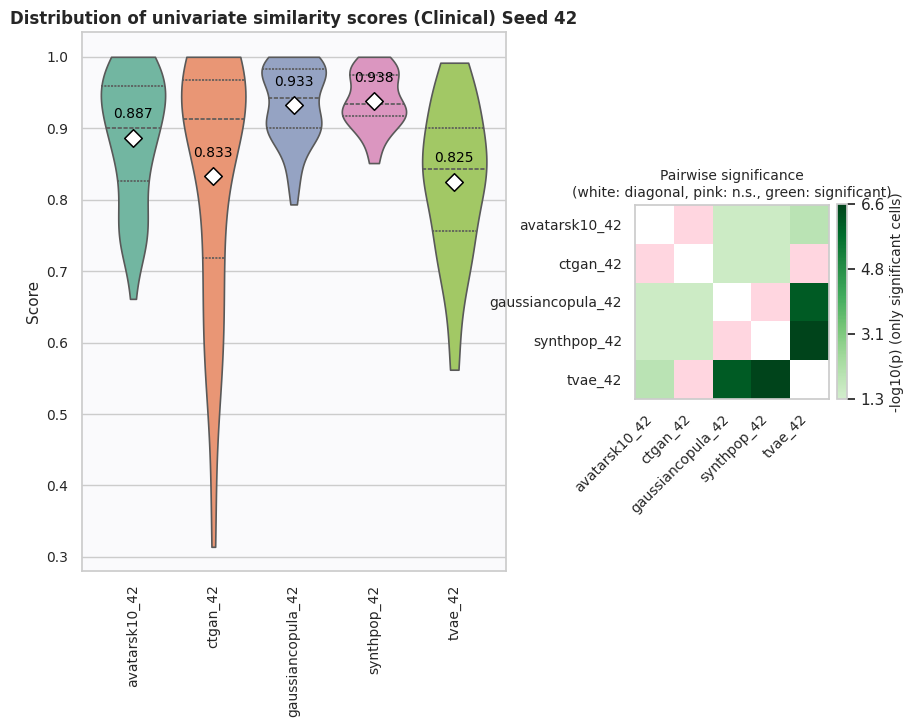

---Seed 0---
---Method avatarsk10_0---
2025-11-30 16:25:10 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:25:10 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1512.63it/s]

2025-11-30 16:25:10 - INFO - Univariate similarity score: 0.8848593476290176
2025-11-30 16:25:10 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_0/Detail_score_avatarsk10_0.csv


2025-11-30 16:25:40 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_0/avatarsk10_0.png
---Method ctgan_0---
2025-11-30 16:25:41 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:25:41 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1790.47it/s]

...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1822.89it/s]

2025-11-30 16:26:40 - INFO - Univariate similarity score: 0.8382425349905887
2025-11-30 16:26:40 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_0/Detail_score_tvae_0.csv


2025-11-30 16:26:44 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_0/tvae_0.png


/tmp/ipykernel_2549104/3330115652.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_green)
/tmp/ipykernel_2549104/3330115652.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2549104/3330115652.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Pairwise p-values used for heatmap (DataFrame):
                  avatarsk10_0  ctgan_0  gaussiancopula_0  synthpop_0  tvae_0
avatarsk10_0            0.0000   0.2757            0.0945      0.0270  0.0270
ctgan_0                 0.2757   0.0000            0.0270      0.0077  0.3582
gaussiancopula_0        0.0945   0.0270            0.0000      0.3582  0.0000
synthpop_0              0.0270   0.0077            0.3582      0.0000  0.0000
tvae_0                  0.0270   0.3582            0.0000      0.0000  0.0000


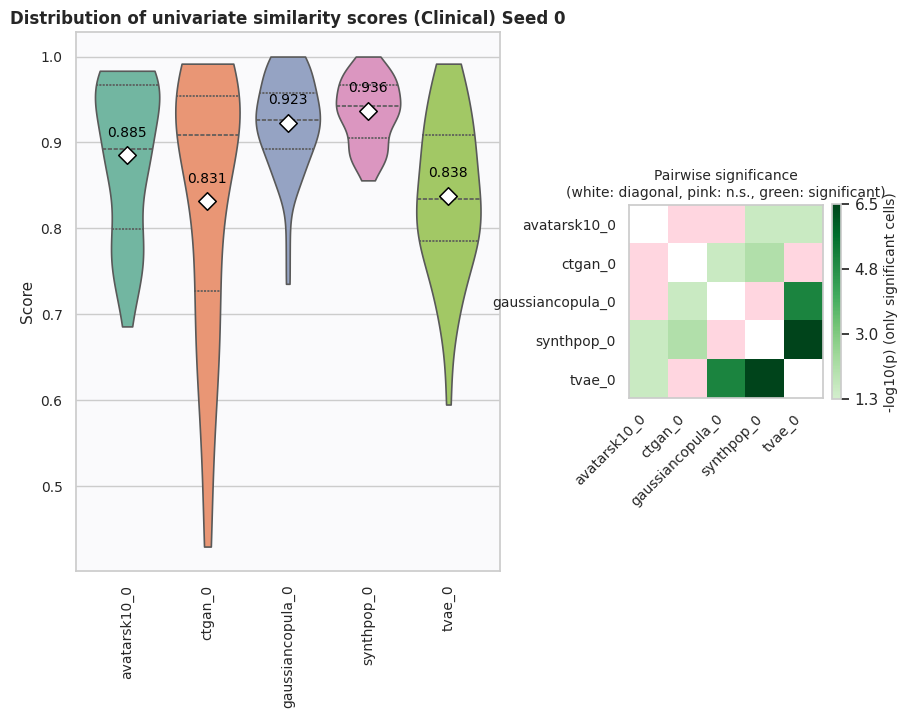

---Seed 1---
---Method avatarsk10_1---
2025-11-30 16:28:55 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:28:55 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1634.22it/s]

2025-11-30 16:28:55 - INFO - Univariate similarity score: 0.8822736083910009
2025-11-30 16:28:55 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_1/Detail_score_avatarsk10_1.csv


2025-11-30 16:29:22 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_1/avatarsk10_1.png
---Method ctgan_1---
2025-11-30 16:29:23 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:29:23 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1948.53it/s]

...

2025-11-30 16:30:46 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_1/synthpop_1.png
---Method tvae_1---
2025-11-30 16:30:48 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:30:48 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 2014.56it/s]

2025-11-30 16:30:48 - INFO - Univariate similarity score: 0.7749742337446154
2025-11-30 16:30:48 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_1/Detail_score_tvae_1.csv


2025-11-30 16:31:15 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_1/tvae_1.png
Pairwise p-values used for heatmap (DataFrame):
                  avatarsk10_1  ctgan_1  gaussiancopula_1  synthpop_1  tvae_1
avatarsk10_1            0.0000   0.8000            0.0686      0.0103  0.0001
ctgan_1                 0.8000   0.0000            0.1458      0.0416  0.0025
gaussiancopula_1        0.0686   0.1458            0.0000      0.3258  0.0000
synthpop_1              0.0103   0.0416            0.3258      0.0000  0.0000
tvae_1                  0.0001   0.0025            0.0000      0.0000  0.0000


/tmp/ipykernel_2549104/3330115652.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_green)
/tmp/ipykernel_2549104/3330115652.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2549104/3330115652.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


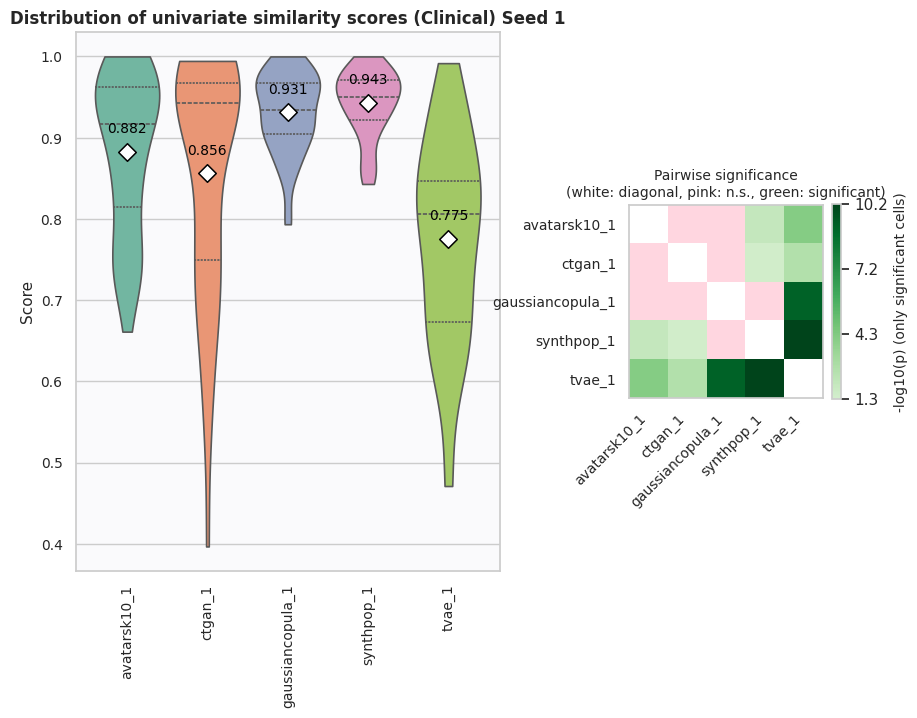

---Seed 2---
---Method avatarsk10_2---
2025-11-30 16:34:35 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:34:35 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1468.80it/s]

2025-11-30 16:34:35 - INFO - Univariate similarity score: 0.8806453601340218
2025-11-30 16:34:35 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_2/Detail_score_avatarsk10_2.csv


2025-11-30 16:35:18 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_2/avatarsk10_2.png
---Method ctgan_2---
2025-11-30 16:35:20 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:35:20 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1729.15it/s]

...

2025-11-30 16:37:19 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_2/synthpop_2.png
---Method tvae_2---
2025-11-30 16:37:20 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:37:20 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1939.67it/s]

2025-11-30 16:37:20 - INFO - Univariate similarity score: 0.8328152258540009


2025-11-30 16:37:21 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_2/Detail_score_tvae_2.csv
2025-11-30 16:37:36 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_2/tvae_2.png
Pairwise p-values used for heatmap (DataFrame):
                  avatarsk10_2  ctgan_2  gaussiancopula_2  synthpop_2  tvae_2
avatarsk10_2            0.0000   0.8441            0.0674      0.0021  0.0422
ctgan_2                 0.8441   0.0000            0.0976      0.0097  0.1335
gaussiancopula_2        0.0674   0.0976            0.0000      0.0976  0.0000
synthpop_2              0.0021   0.0097            0.0976      0.0000  0.0000
tvae_2                  0.0422   0.1335            0.0000      0.0000  0.0000


/tmp/ipykernel_2549104/3330115652.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_green)
/tmp/ipykernel_2549104/3330115652.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2549104/3330115652.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


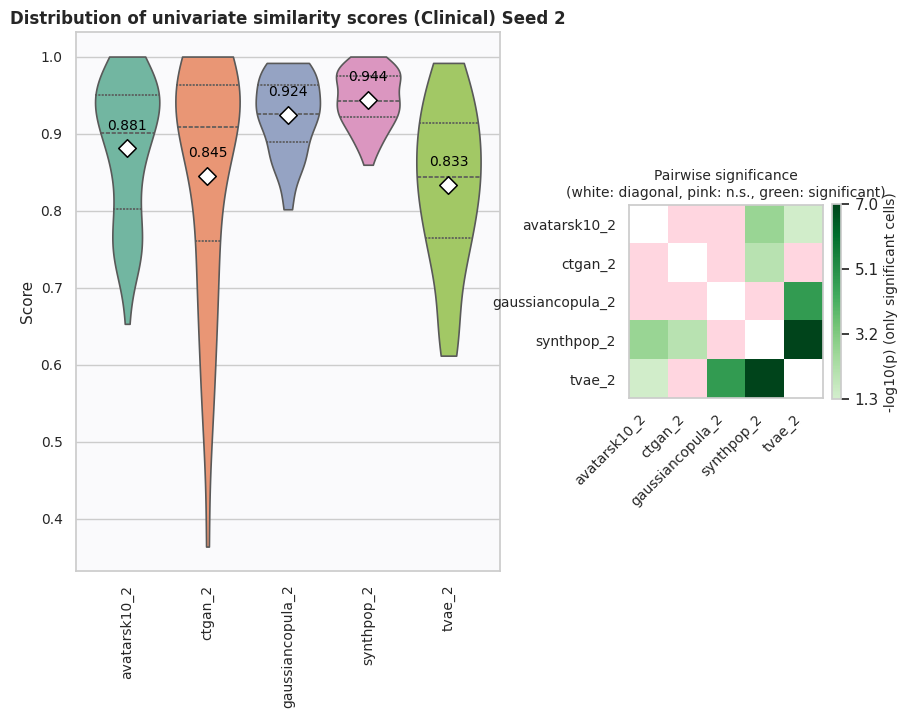

---Seed 3---
---Method avatarsk10_3---
2025-11-30 16:39:34 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:39:34 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 1524.64it/s]

2025-11-30 16:39:34 - INFO - Univariate similarity score: 0.8845618597566539
2025-11-30 16:39:34 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_3/Detail_score_avatarsk10_3.csv


2025-11-30 16:40:01 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_3/avatarsk10_3.png
---Method ctgan_3---
2025-11-30 16:40:02 - DEBUG - Standalone logger initialized successfully.
2025-11-30 16:40:02 - INFO - Starting univariate similarity computation.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 2065.51it/s]

...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:00<00:00, 2122.69it/s]

2025-11-30 16:41:32 - INFO - Univariate similarity score: 0.8222984746070878
2025-11-30 16:41:32 - INFO - Details DataFrame saved to UniClinicalSimi/UniClinicalSimi_3/Detail_score_tvae_3.csv


2025-11-30 16:41:50 - INFO - Histogram figure saved to UniClinicalSimi/UniClinicalSimi_3/tvae_3.png


/tmp/ipykernel_2549104/3330115652.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_green)
/tmp/ipykernel_2549104/3330115652.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2549104/3330115652.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Pairwise p-values used for heatmap (DataFrame):
                  avatarsk10_3  ctgan_3  gaussiancopula_3  synthpop_3  tvae_3
avatarsk10_3            0.0000   0.8294            0.0605      0.0072  0.0019
ctgan_3                 0.8294   0.0000            0.1560      0.0373  0.0373
gaussiancopula_3        0.0605   0.1560            0.0000      0.2563  0.0000
synthpop_3              0.0072   0.0373            0.2563      0.0000  0.0000
tvae_3                  0.0019   0.0373            0.0000      0.0000  0.0000


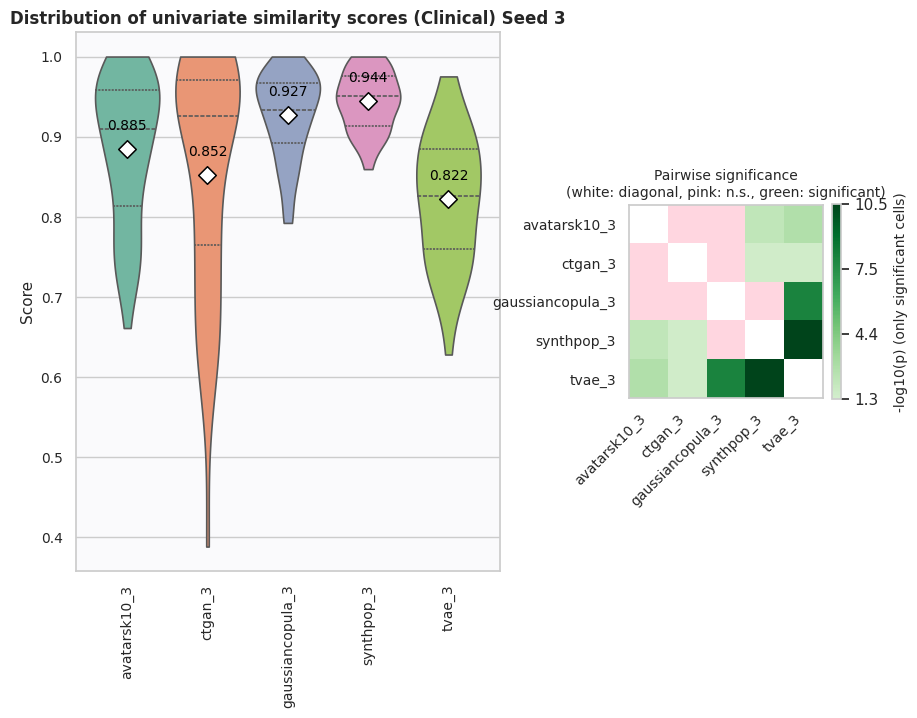

In [3]:
results_all = {}
scores_dfs = {}
for seed in seeds:
    print(f"---Seed {seed}---")
    syn_datas = [f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
    results_seed = {}
    for syn_data in syn_datas:
        print(f"---Method {syn_data}---")
        syn_df = pd.read_csv(f"Data/{syn_data}.csv", index_col = 0)
        clinical_syn_df = syn_df.iloc[:,0:54]
        masked_clinical_syn = post_masking(clinical_syn_df)
        uni_comparison = UnivariateSimilarity(output_dir = f"UniClinicalSimi/UniClinicalSimi_{seed}", logger_name = syn_data)
        scores = uni_comparison.get_univariate_score(
        original_data = masked_clinical_or_data, 
        synthetic_data=masked_clinical_syn, 
        metadata=metadata, save = True
    )
        scores_df = uni_comparison.get_detail_df()
        # scores_df.to_csv(f"UniClinicalSimi/UniClinicalSimi_{seed}/{syn_data}.csv", index = False)
        # scores_dfs[syn_data] = scores_df
        results_seed[syn_data] = scores_df["Score"].values.tolist()
    title = f'Distribution of univariate similarity scores (Clinical) Seed {seed}'
    fig, (ax_v, ax_h), pvals = plot_violin_with_pvalue_heatmap(results_seed, title = title,
                                                           figsize=(16, 7), adjusted=True)
    print("Pairwise p-values used for heatmap (DataFrame):")
    print(pvals.round(4))
    fig.savefig(f"UniClinicalSimi/UniClinicalSimi_{seed}/Benchmark_Uni_Clinical.png", dpi=300, bbox_inches='tight')
    plt.show()
    results_all[seed] = results_seed    

In [14]:
df_gc = pd.read_csv("UniClinicalSimi/UniClinicalSimi_42/gaussiancopula_42.csv")
cat_features = df_gc[df_gc["Metric"]=="TVComplement"]
cat_features_or = cat_features[cat_features["Column"].isin(ordinal_cat_columns)]
cat_features_dummy = cat_features[~cat_features["Column"].isin(ordinal_cat_columns)]
print("Mean Ordinal:", np.mean(cat_features_or["Score"].values.tolist()))
print("Mean Duumy:", np.mean(cat_features_dummy["Score"].values.tolist()))

Mean Ordinal: 0.9383309339984768
Mean Duumy: 0.977152644033129
